## Individual Homework


### Imports


In [72]:
# 1. Imports
import gzip
import os
import random
import shutil
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GCNConv, SAGEConv
from torch_geometric.utils import from_networkx, to_undirected


### Graph Loading


In [73]:
os.makedirs("data", exist_ok=True)

urls = {
    "edges": "https://snap.stanford.edu/data/email-Eu-core.txt.gz",
    "labels": "https://snap.stanford.edu/data/email-Eu-core-department-labels.txt.gz",
}

for name, url in urls.items():
    gz_path = f"data/{name}.gz"
    txt_path = f"data/{name}.txt"

    if not os.path.exists(txt_path):
        urllib.request.urlretrieve(url, gz_path)
        with gzip.open(gz_path, "rb") as f_in, open(txt_path, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)


In [74]:
edges = pd.read_csv(
    "data/edges.txt",
    sep=" ",
    header=None,
    names=["source", "target"],
)
labels = pd.read_csv(
    "data/labels.txt",
    sep=" ",
    header=None,
    names=["node", "department"],
)

print(edges.head())
print(labels.head())

print("Nodes:", labels["node"].nunique())
print("Edges:", len(edges))
print("Classes:", labels["department"].nunique())


   source  target
0       0       1
1       2       3
2       2       4
3       5       6
4       5       7
   node  department
0     0           1
1     1           1
2     2          21
3     3          21
4     4          21
Nodes: 1005
Edges: 25571
Classes: 42


### Graph Building And Calculating Statistics


In [75]:
G = nx.from_pandas_edgelist(
    edges,
    source="source",
    target="target",
    create_using=nx.DiGraph(),
)

self_loop_edges = list(nx.selfloop_edges(G))
if self_loop_edges:
    G.remove_edges_from(self_loop_edges)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Removed self-loops:", len(self_loop_edges))
print("Is directed:", G.is_directed())
print("Is weakly connected:", nx.is_weakly_connected(G))
print("Number of weakly connected components:", nx.number_weakly_connected_components(G))
print("Number of strongly connected components:", nx.number_strongly_connected_components(G))

largest_cc = max(nx.weakly_connected_components(G), key=len)
subG = G.subgraph(list(largest_cc)).to_undirected()
subG.remove_edges_from(nx.selfloop_edges(subG))
centrality = nx.degree_centrality(G)

print("Largest component size:", len(largest_cc))
print("Approx diameter:", nx.diameter(subG))
print(
    "Top 5 nodes by centrality:",
    sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5],
)


Number of nodes: 1005
Number of edges: 24929
Removed self-loops: 642
Is directed: True
Is weakly connected: False
Number of weakly connected components: 20
Number of strongly connected components: 203
Largest component size: 986
Approx diameter: 7
Top 5 nodes by centrality: [(160, 0.5418326693227091), (121, 0.3754980079681275), (107, 0.3695219123505976), (62, 0.3655378486055777), (86, 0.35258964143426297)]


In [76]:
degrees = dict(G.degree())
in_degrees = dict(G.in_degree())
out_degrees = dict(G.out_degree())

print("Average degree:", sum(degrees.values()) / len(degrees))
print("Average in-degree:", sum(in_degrees.values()) / len(in_degrees))
print("Average out-degree:", sum(out_degrees.values()) / len(out_degrees))

G_undirected = G.to_undirected()
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

print("Average clustering coefficient:", nx.average_clustering(G_undirected))
print("Density:", nx.density(G))


Average degree: 49.60995024875622
Average in-degree: 24.80497512437811
Average out-degree: 24.80497512437811
Average clustering coefficient: 0.3993549664221539
Density: 0.024706150522288955


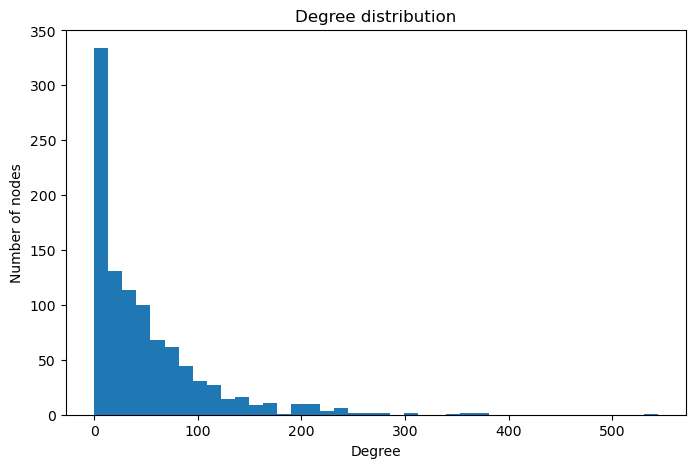

In [77]:
degree_values = list(degrees.values())

plt.figure(figsize=(8, 5))
plt.hist(degree_values, bins=40)
plt.title("Degree distribution")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.show()


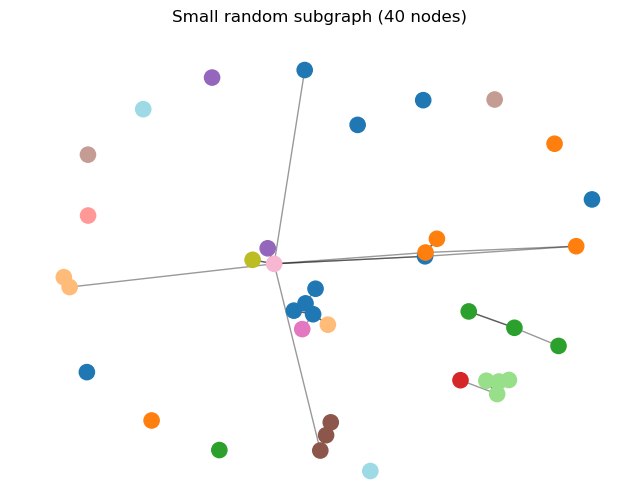

In [78]:
sample_nodes = random.sample(list(G.nodes()), 40)
subG = G.subgraph(sample_nodes).copy()

node_to_label = dict(zip(labels["node"], labels["department"]))
sub_node_colors = [node_to_label.get(node, -1) for node in subG.nodes()]

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(subG, seed=42)

nx.draw_networkx_nodes(
    subG,
    pos,
    node_size=120,
    node_color=sub_node_colors,
    cmap=plt.cm.tab20,
)
nx.draw_networkx_edges(subG, pos, alpha=0.4, arrows=False)

plt.title("Small random subgraph (40 nodes)")
plt.axis("off")
plt.show()


In [79]:
all_nodes = sorted(labels["node"].unique())
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(all_nodes)}

edge_pairs = [
    [node_id_to_idx[src], node_id_to_idx[dst]]
    for src, dst in edges.values
    if src != dst
]

edge_index_directed = torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()

# For department classification, communication in either direction is useful signal.
# Keep G directed for feature engineering, but use undirected edges for GNN message passing.
edge_index = to_undirected(edge_index_directed, num_nodes=len(all_nodes))

labels_sorted = labels.sort_values("node")
y = torch.tensor(labels_sorted["department"].values, dtype=torch.long)

print("directed edge_index shape:", edge_index_directed.shape)
print("message-passing edge_index shape:", edge_index.shape)
print("y shape:", y.shape)
print("Number of classes:", y.max().item() + 1)


directed edge_index shape: torch.Size([2, 24929])
message-passing edge_index shape: torch.Size([2, 32128])
y shape: torch.Size([1005])
Number of classes: 42


In [80]:
num_nodes = len(all_nodes)
G.remove_edges_from(nx.selfloop_edges(G))
G_undirected = G.to_undirected()
G_undirected.remove_edges_from(nx.selfloop_edges(G_undirected))

in_deg = torch.zeros(num_nodes, dtype=torch.float)
out_deg = torch.zeros(num_nodes, dtype=torch.float)
reciprocal_deg = torch.zeros(num_nodes, dtype=torch.float)
edge_set = set((src, dst) for src, dst in edges[["source", "target"]].values.tolist() if src != dst)

for src, dst in edges.values:
    if src == dst:
        continue
    src_idx = node_id_to_idx[src]
    dst_idx = node_id_to_idx[dst]
    out_deg[src_idx] += 1
    in_deg[dst_idx] += 1
    if (dst, src) in edge_set:
        reciprocal_deg[src_idx] += 1
        reciprocal_deg[dst_idx] += 1

total_deg = in_deg + out_deg
reciprocity_ratio = reciprocal_deg / (total_deg + 1e-8)
in_ratio = in_deg / (total_deg + 1e-8)
out_ratio = out_deg / (total_deg + 1e-8)

# Reuse the reference repo's graph-statistics idea, adapted from graph-level
# statistics to node-level structural features for this notebook's node task.
degree_centrality = nx.degree_centrality(G_undirected)
in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)
clustering = nx.clustering(G_undirected)
triangles = nx.triangles(G_undirected)
core_number = nx.core_number(G_undirected)
avg_neighbor_degree = nx.average_neighbor_degree(G_undirected)
pagerank = nx.pagerank(G_undirected, max_iter=1000)
closeness = nx.closeness_centrality(G_undirected)

try:
    hits_hub, hits_authority = nx.hits(G, max_iter=1000, normalized=True)
except nx.PowerIterationFailedConvergence:
    hits_hub = {node: 0.0 for node in all_nodes}
    hits_authority = {node: 0.0 for node in all_nodes}

try:
    eigenvector = nx.eigenvector_centrality(G_undirected, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    eigenvector = {node: 0.0 for node in all_nodes}

# Approximate betweenness keeps the notebook responsive while adding one of the
# centrality signals used in classic graph analysis workflows.
betweenness = nx.betweenness_centrality(
    G_undirected,
    k=min(100, num_nodes),
    seed=42,
    normalized=True,
)

# Node-level analogues of the repo's BFS/component statistics.
hub_node = max(G_undirected.degree(), key=lambda item: item[1])[0]
hub_distance = nx.single_source_shortest_path_length(G_undirected, hub_node)
component_size = {}
for component_nodes in nx.connected_components(G_undirected):
    size = len(component_nodes)
    for node in component_nodes:
        component_size[node] = size

two_hop_neighbors = {}
for node in all_nodes:
    expanded = set(G_undirected.neighbors(node))
    for neighbor in G_undirected.neighbors(node):
        expanded.update(G_undirected.neighbors(neighbor))
    expanded.discard(node)
    two_hop_neighbors[node] = len(expanded)

# Unsupervised community structure is often useful for organization/department graphs.
communities = list(nx.community.greedy_modularity_communities(G_undirected))
node_to_community = {}
for community_id, community_nodes in enumerate(communities):
    for node in community_nodes:
        node_to_community[node] = community_id

community_id = torch.tensor(
    [node_to_community.get(node, -1) for node in all_nodes],
    dtype=torch.long,
)
community_features = torch.nn.functional.one_hot(
    community_id.clamp(min=0),
    num_classes=max(1, len(communities)),
).float()

community_size = {}
community_internal_ratio = {}
community_boundary_ratio = {}
community_neighbor_entropy = {}
for node in all_nodes:
    own_community = node_to_community.get(node, -1)
    neighbors = list(G_undirected.neighbors(node))
    same_community_neighbors = [n for n in neighbors if node_to_community.get(n, -2) == own_community]
    community_size[node] = len(communities[own_community]) if own_community >= 0 else 1
    community_internal_ratio[node] = len(same_community_neighbors) / max(1, len(neighbors))
    community_boundary_ratio[node] = 1.0 - community_internal_ratio[node]

    neighbor_communities = [node_to_community.get(n, -1) for n in neighbors]
    if neighbor_communities:
        counts = np.bincount(neighbor_communities, minlength=max(1, len(communities))).astype(float)
        probs = counts / counts.sum()
        community_neighbor_entropy[node] = float(-(probs[probs > 0] * np.log(probs[probs > 0])).sum() / np.log(max(2, len(communities))))
    else:
        community_neighbor_entropy[node] = 0.0

# Spectral positional encodings capture global graph position without using labels.
spectral_dim = 16
try:
    spectral_adj = torch.zeros((num_nodes, num_nodes), dtype=torch.float)
    spectral_adj[edge_index[0], edge_index[1]] = 1.0
    spectral_adj.fill_diagonal_(1.0)
    spectral_degree = spectral_adj.sum(dim=1).clamp(min=1.0)
    spectral_norm = spectral_adj / torch.sqrt(spectral_degree[:, None] * spectral_degree[None, :])
    _, spectral_vectors = torch.linalg.eigh(spectral_norm)
    spectral_features = spectral_vectors[:, -(spectral_dim + 1):-1]
except Exception as exc:
    print("Spectral features failed; using zeros:", exc)
    spectral_features = torch.zeros((num_nodes, spectral_dim), dtype=torch.float)

spectral_features = torch.nan_to_num(spectral_features, nan=0.0, posinf=0.0, neginf=0.0)
spectral_features = (spectral_features - spectral_features.mean(dim=0)) / (spectral_features.std(dim=0) + 1e-8)

def neighbor_mean(values, node):
    neighbors = list(G_undirected.neighbors(node))
    if not neighbors:
        return 0.0
    return float(np.mean([values[neighbor] for neighbor in neighbors]))


def neighbor_std(values, node):
    neighbors = list(G_undirected.neighbors(node))
    if len(neighbors) <= 1:
        return 0.0
    return float(np.std([values[neighbor] for neighbor in neighbors]))


def neighbor_max(values, node):
    neighbors = list(G_undirected.neighbors(node))
    if not neighbors:
        return 0.0
    return float(np.max([values[neighbor] for neighbor in neighbors]))


def directed_neighbor_mean(values, neighbors):
    neighbors = list(neighbors)
    if not neighbors:
        return 0.0
    return float(np.mean([values[neighbor] for neighbor in neighbors]))

node_total_degree = {node: float(total_deg[node_id_to_idx[node]].item()) for node in all_nodes}
node_in_degree = {node: float(in_deg[node_id_to_idx[node]].item()) for node in all_nodes}
node_out_degree = {node: float(out_deg[node_id_to_idx[node]].item()) for node in all_nodes}

feature_columns = {
    "log_in_degree": torch.log1p(in_deg),
    "log_out_degree": torch.log1p(out_deg),
    "log_total_degree": torch.log1p(total_deg),
    "in_ratio": in_ratio,
    "out_ratio": out_ratio,
    "reciprocity_ratio": reciprocity_ratio,
    "log_degree_product": torch.log1p(in_deg * out_deg),
    "abs_in_out_diff": torch.abs(in_deg - out_deg),
    "signed_in_out_balance": (in_deg - out_deg) / (total_deg + 1e-8),
    "degree_centrality": torch.tensor([degree_centrality[node] for node in all_nodes], dtype=torch.float),
    "in_degree_centrality": torch.tensor([in_degree_centrality[node] for node in all_nodes], dtype=torch.float),
    "out_degree_centrality": torch.tensor([out_degree_centrality[node] for node in all_nodes], dtype=torch.float),
    "clustering": torch.tensor([clustering[node] for node in all_nodes], dtype=torch.float),
    "log_triangles": torch.log1p(torch.tensor([triangles[node] for node in all_nodes], dtype=torch.float)),
    "core_number": torch.tensor([core_number[node] for node in all_nodes], dtype=torch.float),
    "avg_neighbor_degree": torch.tensor([avg_neighbor_degree[node] for node in all_nodes], dtype=torch.float),
    "pagerank": torch.tensor([pagerank[node] for node in all_nodes], dtype=torch.float),
    "closeness": torch.tensor([closeness[node] for node in all_nodes], dtype=torch.float),
    "hits_hub": torch.tensor([hits_hub[node] for node in all_nodes], dtype=torch.float),
    "hits_authority": torch.tensor([hits_authority[node] for node in all_nodes], dtype=torch.float),
    "eigenvector": torch.tensor([eigenvector[node] for node in all_nodes], dtype=torch.float),
    "betweenness_approx": torch.tensor([betweenness[node] for node in all_nodes], dtype=torch.float),
    "hub_distance": torch.tensor([hub_distance.get(node, num_nodes) for node in all_nodes], dtype=torch.float),
    "component_size": torch.log1p(torch.tensor([component_size.get(node, 1) for node in all_nodes], dtype=torch.float)),
    "log_two_hop_neighbors": torch.log1p(torch.tensor([two_hop_neighbors[node] for node in all_nodes], dtype=torch.float)),
    "log_community_size": torch.log1p(torch.tensor([community_size[node] for node in all_nodes], dtype=torch.float)),
    "community_internal_ratio": torch.tensor([community_internal_ratio[node] for node in all_nodes], dtype=torch.float),
    "community_boundary_ratio": torch.tensor([community_boundary_ratio[node] for node in all_nodes], dtype=torch.float),
    "community_neighbor_entropy": torch.tensor([community_neighbor_entropy[node] for node in all_nodes], dtype=torch.float),
    "neighbor_mean_total_degree": torch.tensor([neighbor_mean(node_total_degree, node) for node in all_nodes], dtype=torch.float),
    "neighbor_std_total_degree": torch.tensor([neighbor_std(node_total_degree, node) for node in all_nodes], dtype=torch.float),
    "neighbor_max_total_degree": torch.tensor([neighbor_max(node_total_degree, node) for node in all_nodes], dtype=torch.float),
    "neighbor_mean_pagerank": torch.tensor([neighbor_mean(pagerank, node) for node in all_nodes], dtype=torch.float),
    "neighbor_mean_clustering": torch.tensor([neighbor_mean(clustering, node) for node in all_nodes], dtype=torch.float),
    "predecessor_mean_out_degree": torch.tensor([directed_neighbor_mean(node_out_degree, G.predecessors(node)) for node in all_nodes], dtype=torch.float),
    "successor_mean_in_degree": torch.tensor([directed_neighbor_mean(node_in_degree, G.successors(node)) for node in all_nodes], dtype=torch.float),
}

structural_feature_names = list(feature_columns.keys())
structural_x = torch.stack(list(feature_columns.values()), dim=1)
structural_x = torch.nan_to_num(structural_x, nan=0.0, posinf=0.0, neginf=0.0)
structural_x = (structural_x - structural_x.mean(dim=0)) / (structural_x.std(dim=0) + 1e-8)

# Community one-hot features are already scaled binary indicators.
x = torch.cat([structural_x, community_features, spectral_features], dim=1)
feature_names = (
    structural_feature_names
    + [f"community_{i}" for i in range(community_features.size(1))]
    + [f"spectral_pos_{i}" for i in range(spectral_features.size(1))]
)

print("Structural feature count:", len(structural_feature_names))
print("Detected communities:", len(communities))
print("Spectral feature count:", spectral_features.size(1))
print("x shape:", x.shape)
print("First feature names:", feature_names[:10])


Structural feature count: 36
Detected communities: 27
Spectral feature count: 16
x shape: torch.Size([1005, 79])
First feature names: ['log_in_degree', 'log_out_degree', 'log_total_degree', 'in_ratio', 'out_ratio', 'reciprocity_ratio', 'log_degree_product', 'abs_in_out_diff', 'signed_in_out_balance', 'degree_centrality']


In [81]:
class_counts = Counter(y.numpy())
valid_classes = sorted(cls for cls, count in class_counts.items() if count >= 5)
class_to_idx = {cls: idx for idx, cls in enumerate(valid_classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

y_mapped = torch.full_like(y, fill_value=-1)
for original_class, mapped_class in class_to_idx.items():
    y_mapped[y == original_class] = mapped_class

valid_node_mask = y_mapped >= 0
valid_indices = valid_node_mask.nonzero(as_tuple=True)[0]

print("Original nodes:", len(y))
print("Remaining nodes:", len(valid_indices))
print("Original classes:", len(class_counts))
print("Remaining classes:", len(valid_classes))


Original nodes: 1005
Remaining nodes: 987
Original classes: 42
Remaining classes: 35


In [82]:
train_idx, temp_idx = train_test_split(
    valid_indices.numpy(),
    test_size=0.4,
    random_state=42,
    stratify=y_mapped[valid_indices].numpy(),
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.5,
    random_state=42,
    stratify=y_mapped[temp_idx].numpy(),
)

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data = Data(
    x=x,
    edge_index=edge_index,
    y=y_mapped,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

print(data)
print("Train nodes:", train_mask.sum().item())
print("Validation nodes:", val_mask.sum().item())
print("Test nodes:", test_mask.sum().item())


Data(x=[1005, 79], edge_index=[2, 32128], y=[1005], train_mask=[1005], val_mask=[1005], test_mask=[1005])
Train nodes: 592
Validation nodes: 197
Test nodes: 198


### Train-Label Propagation Features


In [83]:
label_feature_classes = int(data.y.max().item()) + 1
label_seed = torch.zeros((num_nodes, label_feature_classes), dtype=torch.float)
label_seed[data.train_mask] = torch.nn.functional.one_hot(
    data.y[data.train_mask],
    num_classes=label_feature_classes,
).float()

adj_binary = torch.zeros((num_nodes, num_nodes), dtype=torch.float)
adj_binary[data.edge_index[0], data.edge_index[1]] = 1.0
adj_no_self = adj_binary.clone()
adj_no_self.fill_diagonal_(0.0)

adj = adj_no_self.clone()
adj.fill_diagonal_(1.0)
adj = adj / adj.sum(dim=1, keepdim=True).clamp(min=1.0)
adj_neighbors = adj_no_self / adj_no_self.sum(dim=1, keepdim=True).clamp(min=1.0)

train_indicator = data.train_mask.float().view(-1, 1)
one_hop_train_coverage = adj_neighbors @ train_indicator
one_hop_label_dist = adj_neighbors @ label_seed

two_hop_reach = (adj_no_self @ adj_no_self > 0).float()
two_hop_reach.fill_diagonal_(0.0)
two_hop_norm = two_hop_reach / two_hop_reach.sum(dim=1, keepdim=True).clamp(min=1.0)
two_hop_train_coverage = two_hop_norm @ train_indicator
two_hop_label_dist = two_hop_norm @ label_seed

label_feature_blocks = [
    one_hop_label_dist,
    one_hop_train_coverage,
    two_hop_label_dist,
    two_hop_train_coverage,
]
label_feature_names = (
    [f"train_label_1hop_{i}" for i in range(label_feature_classes)]
    + ["train_label_1hop_coverage"]
    + [f"train_label_2hop_{i}" for i in range(label_feature_classes)]
    + ["train_label_2hop_coverage"]
)

for steps, alpha in [(2, 0.50), (4, 0.80), (8, 0.95)]:
    label_signal = label_seed.clone()
    for _ in range(steps):
        label_signal = alpha * adj @ label_signal + (1 - alpha) * label_seed
        label_signal[data.train_mask] = label_seed[data.train_mask]

    label_confidence = label_signal.max(dim=1, keepdim=True).values
    label_entropy = -(
        label_signal.clamp(min=1e-12) * label_signal.clamp(min=1e-12).log()
    ).sum(dim=1, keepdim=True)
    label_entropy = label_entropy / np.log(label_feature_classes)

    label_feature_blocks.extend([label_signal, label_confidence, label_entropy])
    suffix = f"steps{steps}_alpha{str(alpha).replace('.', '')}"
    label_feature_names.extend([f"train_label_prop_{suffix}_{i}" for i in range(label_feature_classes)])
    label_feature_names.extend([
        f"train_label_prop_{suffix}_confidence",
        f"train_label_prop_{suffix}_entropy",
    ])

label_propagation_features = torch.cat(label_feature_blocks, dim=1)
label_propagation_features = torch.nan_to_num(label_propagation_features, nan=0.0, posinf=0.0, neginf=0.0)

data.x = torch.cat([data.x, label_propagation_features], dim=1)
feature_names = feature_names + label_feature_names

print("Train-label feature count:", label_propagation_features.size(1))
print("Updated x shape:", data.x.shape)


Train-label feature count: 183
Updated x shape: torch.Size([1005, 262])


### Model Training And Evaluation


In [84]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_features = data.num_node_features
num_classes = int(data.y.max().item()) + 1

print("Device:", device)
print("Number of features:", num_features)
print("Number of classes:", num_classes)


Device: cpu
Number of features: 262
Number of classes: 35


In [85]:
class GNN(torch.nn.Module):
    def __init__(
        self,
        model_name,
        in_channels,
        hidden_channels,
        out_channels,
        dropout=0.5,
        heads=4,
    ):
        super().__init__()
        self.model_name = model_name
        self.dropout = dropout

        if model_name == "GCN":
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, out_channels)
        elif model_name == "GraphSAGE":
            self.conv1 = SAGEConv(in_channels, hidden_channels)
            self.conv2 = SAGEConv(hidden_channels, out_channels)
        elif model_name == "GAT":
            self.conv1 = GATConv(
                in_channels,
                hidden_channels,
                heads=heads,
                dropout=dropout,
            )
            self.conv2 = GATConv(
                hidden_channels * heads,
                out_channels,
                heads=1,
                concat=False,
                dropout=dropout,
            )
        else:
            raise ValueError(f"Unknown model: {model_name}")

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = torch.nn.functional.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


In [86]:
def evaluate_model(model, graph_data):
    model.eval()
    with torch.no_grad():
        logits = model(graph_data.x, graph_data.edge_index)
        pred = logits.argmax(dim=1)

    scores = {}
    for split_name, mask in {
        "train": graph_data.train_mask,
        "val": graph_data.val_mask,
        "test": graph_data.test_mask,
    }.items():
        y_true = graph_data.y[mask].detach().cpu().numpy()
        y_pred = pred[mask].detach().cpu().numpy()
        scores[f"{split_name}_accuracy"] = accuracy_score(y_true, y_pred)
        scores[f"{split_name}_f1_macro"] = f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        )

    return scores, pred.detach().cpu()


def train_model(
    model_name,
    hidden_channels=32,
    lr=0.01,
    weight_decay=5e-4,
    dropout=0.5,
    heads=4,
    epochs=150,
    patience=30,
):
    torch.manual_seed(42)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(42)

    graph_data = data.clone().to(device)
    model = GNN(
        model_name=model_name,
        in_channels=num_features,
        hidden_channels=hidden_channels,
        out_channels=num_classes,
        dropout=dropout,
        heads=heads,
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_state = None
    best_val_loss = float("inf")
    best_epoch = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        logits = model(graph_data.x, graph_data.edge_index)
        loss = torch.nn.functional.cross_entropy(
            logits[graph_data.train_mask],
            graph_data.y[graph_data.train_mask],
        )
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(graph_data.x, graph_data.edge_index)
            val_loss = torch.nn.functional.cross_entropy(
                val_logits[graph_data.val_mask],
                graph_data.y[graph_data.val_mask],
            )

        scores, _ = evaluate_model(model, graph_data)
        history.append(
            {
                "epoch": epoch,
                "loss": float(loss.item()),
                "val_loss": float(val_loss.item()),
                **scores,
            }
        )

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            best_epoch = epoch
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        if epoch - best_epoch >= patience:
            break

    model.load_state_dict(best_state)
    final_scores, pred = evaluate_model(model, graph_data)

    return {
        "model": model_name,
        "hidden_channels": hidden_channels,
        "lr": lr,
        "weight_decay": weight_decay,
        "dropout": dropout,
        "heads": heads if model_name == "GAT" else None,
        "best_epoch": best_epoch,
        **final_scores,
        "trained_model": model.cpu(),
        "predictions": pred,
        "history": pd.DataFrame(history),
    }


### Architecture Comparison With Fixed Parameters


In [87]:
fixed_model_configs = [
    {
        "model_name": "GCN",
        "hidden_channels": 32,
        "lr": 0.01,
        "dropout": 0.5,
        "heads": 1,
    },
    {
        "model_name": "GraphSAGE",
        "hidden_channels": 32,
        "lr": 0.01,
        "dropout": 0.5,
        "heads": 1,
    },
    {
        "model_name": "GAT",
        "hidden_channels": 32,
        "lr": 0.01,
        "dropout": 0.5,
        "heads": 4,
    },
]

results = []
trained_runs = []

for params in fixed_model_configs:
    run = train_model(
        **params,
        weight_decay=5e-4,
        epochs=150,
        patience=30,
    )
    run["run_id"] = len(trained_runs)
    trained_runs.append(run)
    results.append(
        {
            key: value
            for key, value in run.items()
            if key not in {"trained_model", "predictions", "history"}
        }
    )
    print(
        f"{run['model']:9s} | hidden={run['hidden_channels']:2d} "
        f"lr={run['lr']:.3f} dropout={run['dropout']:.1f} "
        f"val_acc={run['val_accuracy']:.3f} test_acc={run['test_accuracy']:.3f}"
    )

results_df = pd.DataFrame(results).sort_values(
    by=["model"],
    ascending=True,
).reset_index(drop=True)

results_df


GCN       | hidden=32 lr=0.010 dropout=0.5 val_acc=0.746 test_acc=0.707
GraphSAGE | hidden=32 lr=0.010 dropout=0.5 val_acc=0.711 test_acc=0.682
GAT       | hidden=32 lr=0.010 dropout=0.5 val_acc=0.766 test_acc=0.783


,model,hidden_channels,lr,weight_decay,dropout,heads,best_epoch,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro,run_id
0,GAT,32,0.01,0.0005,0.5,4.0,119,0.954392,0.919564,0.766497,0.623070,0.782828,0.663005,2
1,GCN,32,0.01,0.0005,0.5,NaN,146,0.900338,0.827275,0.746193,0.564299,0.707071,0.544855,0
2,GraphSAGE,32,0.01,0.0005,0.5,NaN,35,0.998311,0.993859,0.710660,0.537438,0.681818,0.505787,1


In [88]:
# Select the strongest fixed-parameter run only for plotting/prediction below.
best_config = results_df.sort_values(
    by=["val_accuracy", "val_f1_macro"],
    ascending=False,
).iloc[0]
best_run = trained_runs[int(best_config["run_id"])]

print("Best fixed-parameter model:")
print(best_config)

summary_columns = [
    "model",
    "hidden_channels",
    "lr",
    "dropout",
    "heads",
    "best_epoch",
    "train_accuracy",
    "train_f1_macro",
    "val_accuracy",
    "val_f1_macro",
    "test_accuracy",
    "test_f1_macro",
]

results_df[summary_columns]


Best fixed-parameter model:
model                   GAT
hidden_channels          32
lr                     0.01
weight_decay         0.0005
dropout                 0.5
heads                   4.0
best_epoch              119
train_accuracy     0.954392
train_f1_macro     0.919564
val_accuracy       0.766497
val_f1_macro        0.62307
test_accuracy      0.782828
test_f1_macro      0.663005
run_id                    2
Name: 0, dtype: object


,model,hidden_channels,lr,dropout,heads,best_epoch,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro,test_accuracy,test_f1_macro
0,GAT,32,0.01,0.5,4.0,119,0.954392,0.919564,0.766497,0.623070,0.782828,0.663005
1,GCN,32,0.01,0.5,NaN,146,0.900338,0.827275,0.746193,0.564299,0.707071,0.544855
2,GraphSAGE,32,0.01,0.5,NaN,35,0.998311,0.993859,0.710660,0.537438,0.681818,0.505787


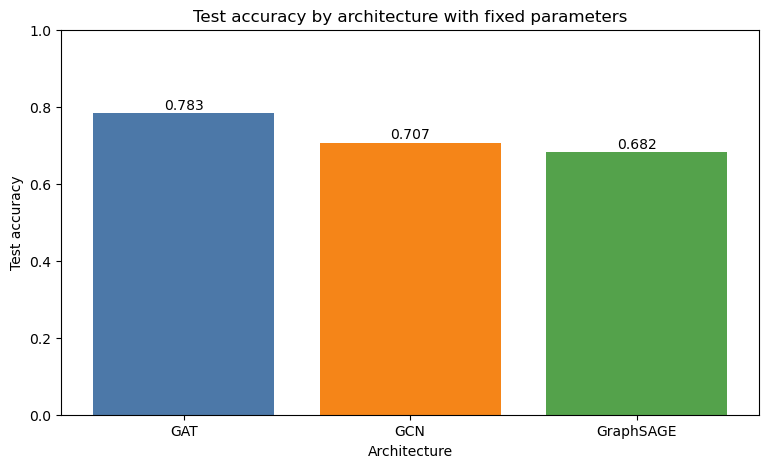

In [89]:
plt.figure(figsize=(9, 5))

plot_df = results_df.sort_values("model")
plt.bar(
    plot_df["model"],
    plot_df["test_accuracy"],
    color=["#4c78a8", "#f58518", "#54a24b"],
)

for index, row in plot_df.reset_index(drop=True).iterrows():
    plt.text(
        index,
        row["test_accuracy"] + 0.01,
        f"{row['test_accuracy']:.3f}",
        ha="center",
    )

plt.title("Test accuracy by architecture with fixed parameters")
plt.xlabel("Architecture")
plt.ylabel("Test accuracy")
plt.ylim(0, 1)
plt.show()


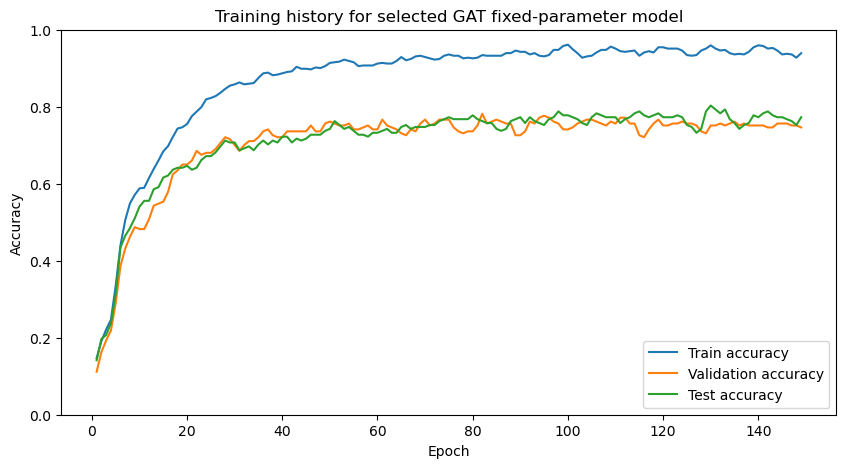

In [90]:
history = best_run["history"]

plt.figure(figsize=(10, 5))
plt.plot(history["epoch"], history["train_accuracy"], label="Train accuracy")
plt.plot(history["epoch"], history["val_accuracy"], label="Validation accuracy")
plt.plot(history["epoch"], history["test_accuracy"], label="Test accuracy")
plt.title(f"Training history for selected {best_run['model']} fixed-parameter model")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.show()


### Prediction Visualization On A Subgraph


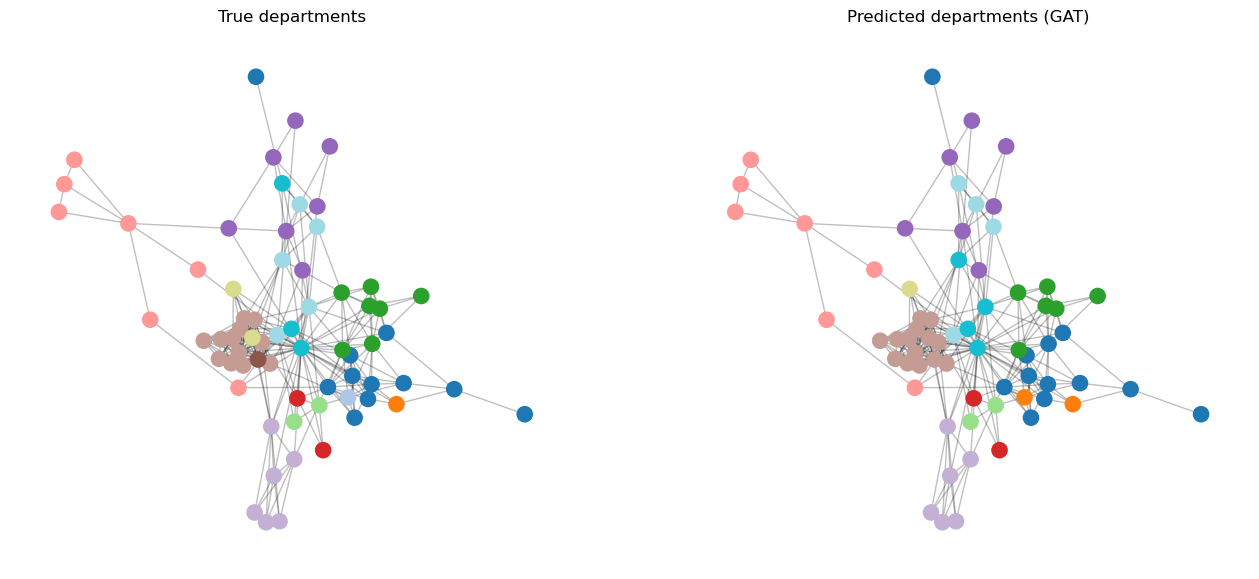

In [91]:
predictions = best_run["predictions"]
idx_to_node_id = {idx: node_id for node_id, idx in node_id_to_idx.items()}

test_indices = test_mask.nonzero(as_tuple=True)[0].tolist()
random.seed(42)
center_indices = random.sample(test_indices, min(12, len(test_indices)))
center_nodes = [idx_to_node_id[idx] for idx in center_indices]

visual_nodes = set(center_nodes)
for node in center_nodes:
    visual_nodes.update(list(G.predecessors(node))[:4])
    visual_nodes.update(list(G.successors(node))[:4])

visual_nodes = list(visual_nodes)[:90]
visual_subgraph = G.subgraph(visual_nodes).to_undirected().copy()
pos = nx.spring_layout(visual_subgraph, seed=42)

true_colors = [
    class_to_idx.get(node_to_label.get(node, -1), -1)
    for node in visual_subgraph.nodes()
]
pred_colors = [
    predictions[node_id_to_idx[node]].item()
    if node_id_to_idx[node] in valid_indices.tolist()
    else -1
    for node in visual_subgraph.nodes()
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, colors, title in zip(
    axes,
    [true_colors, pred_colors],
    ["True departments", f"Predicted departments ({best_run['model']})"],
):
    nx.draw_networkx_nodes(
        visual_subgraph,
        pos,
        node_size=120,
        node_color=colors,
        cmap=plt.cm.tab20,
        ax=ax,
    )
    nx.draw_networkx_edges(
        visual_subgraph,
        pos,
        alpha=0.25,
        ax=ax,
    )
    ax.set_title(title)
    ax.axis("off")

plt.show()
